# Language Detection — Model Building & Evaluation

Vectorize the cleaned text with TF-IDF, train 7 classifiers, compare them, run cross-validation, and tune the best performer with GridSearchCV.

## 1. Imports & Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression, RidgeClassifier, PassiveAggressiveClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from utils import evaluate_model, plot_confusion_matrix, compare_models
sns.set_style('whitegrid')
%matplotlib inline

In [2]:
df = pd.read_csv('data/language_cleaned.csv').dropna(subset=['clean_text'])
print('Shape:', df.shape)
df.head()

Shape: (10267, 2)


,clean_text,label
0,nature in the broadest sense is the natural ph...,3
1,nature can refer to the phenomena of the physi...,3
2,the study of nature is a large if not the only...,3
3,although humans are part of nature human activ...,3
4,the word nature is borrowed from the old frenc...,3


## 2. TF-IDF Vectorization & Train/Test Split

In [3]:
X_text = df['clean_text'].astype(str)
y = df['label']
X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y)
vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(1, 3), max_features=12000, sublinear_tf=True)
X_train = vectorizer.fit_transform(X_train_txt)
X_test = vectorizer.transform(X_test_txt)
print('TF-IDF train matrix:', X_train.shape)
print('TF-IDF test matrix :', X_test.shape)

TF-IDF train matrix: (8213, 12000)
TF-IDF test matrix : (2054, 12000)


## 3. Train 7 Classifiers

In [4]:
results = []
models = {}


  Multinomial NB
  Accuracy    : 0.9596
  Precision   : 0.9655
  Recall      : 0.9596
  F1 Score    : 0.9597


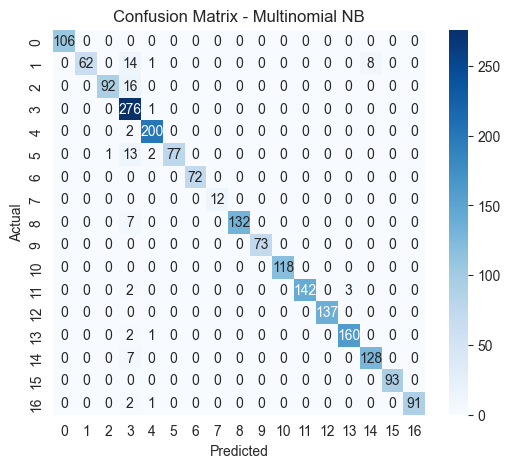

In [5]:
mnb = MultinomialNB()
mnb.fit(X_train, y_train)
y_pred = mnb.predict(X_test)
results.append(evaluate_model('Multinomial NB', y_test, y_pred))
models['Multinomial NB'] = mnb
plot_confusion_matrix(y_test, y_pred, 'Multinomial NB'); plt.show()


  Complement NB
  Accuracy    : 0.9796
  Precision   : 0.9802
  Recall      : 0.9796
  F1 Score    : 0.9794


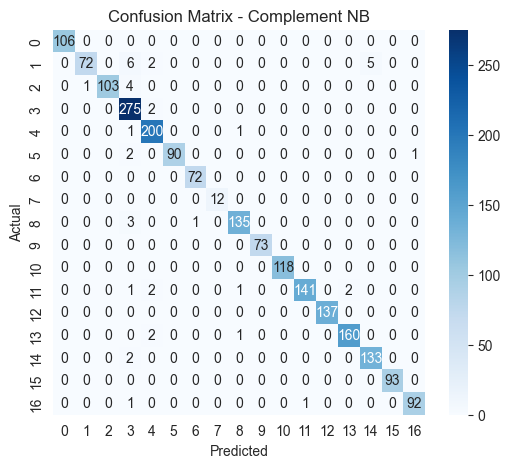

In [6]:
cnb = ComplementNB()
cnb.fit(X_train, y_train)
y_pred = cnb.predict(X_test)
results.append(evaluate_model('Complement NB', y_test, y_pred))
models['Complement NB'] = cnb
plot_confusion_matrix(y_test, y_pred, 'Complement NB'); plt.show()


  Logistic Regression
  Accuracy    : 0.9869
  Precision   : 0.9869
  Recall      : 0.9869
  F1 Score    : 0.9868


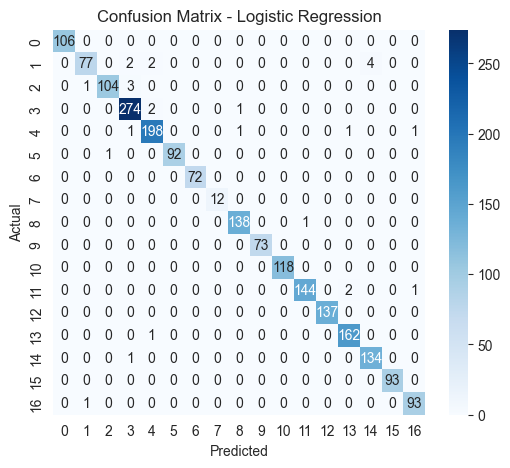

In [7]:
lr = LogisticRegression(max_iter=2000, C=1.0)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
results.append(evaluate_model('Logistic Regression', y_test, y_pred))
models['Logistic Regression'] = lr
plot_confusion_matrix(y_test, y_pred, 'Logistic Regression'); plt.show()


  Linear SVM
  Accuracy    : 0.9888
  Precision   : 0.9889
  Recall      : 0.9888
  F1 Score    : 0.9888


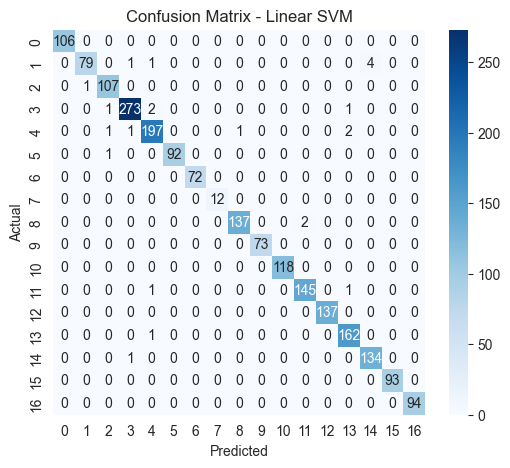

In [8]:
svm = LinearSVC(C=1.0)
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)
results.append(evaluate_model('Linear SVM', y_test, y_pred))
models['Linear SVM'] = svm
plot_confusion_matrix(y_test, y_pred, 'Linear SVM'); plt.show()


  Ridge Classifier
  Accuracy    : 0.9898
  Precision   : 0.9898
  Recall      : 0.9898
  F1 Score    : 0.9898


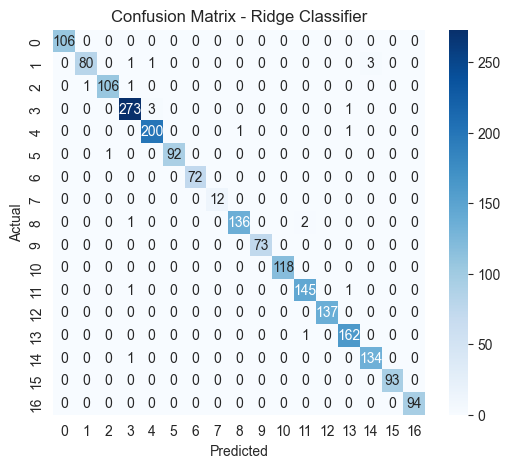

In [9]:
ridge = RidgeClassifier()
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)
results.append(evaluate_model('Ridge Classifier', y_test, y_pred))
models['Ridge Classifier'] = ridge
plot_confusion_matrix(y_test, y_pred, 'Ridge Classifier'); plt.show()


  Passive Aggressive
  Accuracy    : 0.9888
  Precision   : 0.9888
  Recall      : 0.9888
  F1 Score    : 0.9888


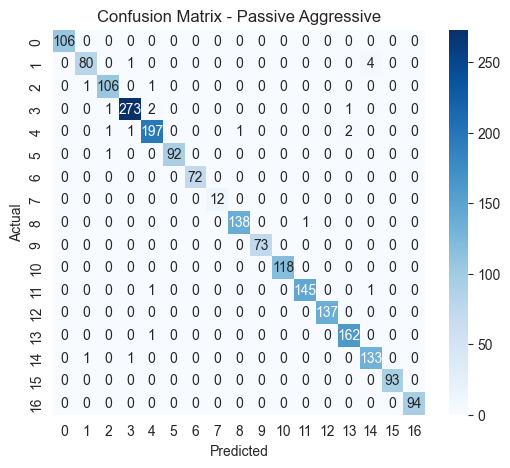

In [10]:
pac = PassiveAggressiveClassifier(max_iter=1000, random_state=42)
pac.fit(X_train, y_train)
y_pred = pac.predict(X_test)
results.append(evaluate_model('Passive Aggressive', y_test, y_pred))
models['Passive Aggressive'] = pac
plot_confusion_matrix(y_test, y_pred, 'Passive Aggressive'); plt.show()


  Random Forest
  Accuracy    : 0.9722
  Precision   : 0.9726
  Recall      : 0.9722
  F1 Score    : 0.9723


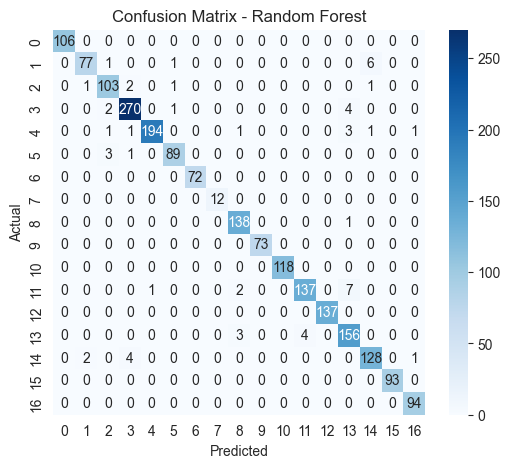

In [11]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
results.append(evaluate_model('Random Forest', y_test, y_pred))
models['Random Forest'] = rf
plot_confusion_matrix(y_test, y_pred, 'Random Forest'); plt.show()

## 4. Model Comparison

In [12]:
comparison = compare_models(results)
comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Ridge Classifier,0.989776,0.989817,0.989776,0.989757
1,Passive Aggressive,0.988802,0.988842,0.988802,0.988795
2,Linear SVM,0.988802,0.988867,0.988802,0.988777
3,Logistic Regression,0.986855,0.986898,0.986855,0.986789
4,Complement NB,0.979552,0.980199,0.979552,0.979434
5,Random Forest,0.972249,0.972610,0.972249,0.972260
6,Multinomial NB,0.959591,0.965537,0.959591,0.959659


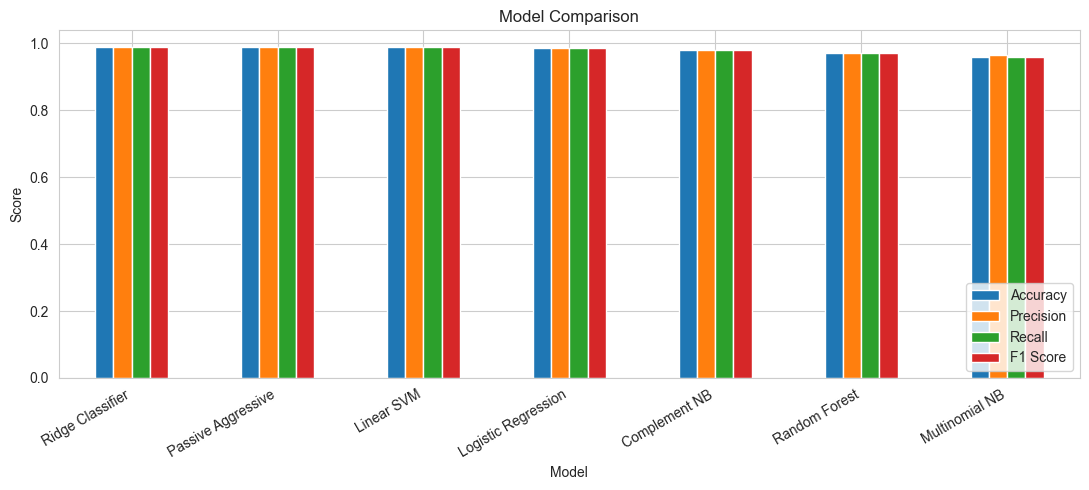

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
comparison.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1 Score']].plot(kind='bar', ax=ax)
ax.set_title('Model Comparison'); ax.set_ylabel('Score')
plt.xticks(rotation=30, ha='right'); plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

## 5. Top Predictive Words (best linear model)

In [14]:
best_linear = models.get('Logistic Regression')
feature_names = np.array(vectorizer.get_feature_names_out())
if best_linear is not None and hasattr(best_linear, 'coef_'):
    coefs = best_linear.coef_
    if coefs.shape[0] == 1:
        top_pos = feature_names[np.argsort(coefs[0])[-15:]]
        top_neg = feature_names[np.argsort(coefs[0])[:15]]
        print('Words pushing toward the positive class:'); print(list(top_pos))
        print('\nWords pushing toward the negative class:'); print(list(top_neg))
    else:
        for ci in range(min(coefs.shape[0], 4)):
            top = feature_names[np.argsort(coefs[ci])[-12:]]
            print(f'Class {ci} top words:', list(top))

Class 0 top words: [' ا', 'ر', 'ك', 'ا ', 'أ', 'ع', 'ت', 'ن', 'م', 'ي', 'ل', 'ا']
Class 1 top words: [' hv', 'det', 'et ', 'jeg', ' og', 'og', 'og ', 'g', 'er ', 'g ', 'æ', 'ø']
Class 2 top words: [' z', 'k ', 'oo', 'n ', 'het', ' he', 'j', 'oe', 'en ', 'ee', 'ij', 'aa']
Class 3 top words: ['w', 'ng ', 'h', 'ea', 'ed ', ' t', 'y ', 'd ', 'y', 'the', ' th', 'th']


## 6. 5-Fold Cross-Validation

In [15]:
X_all = vectorizer.fit_transform(X_text)
cv_scores = {}
for name, model in models.items():
    scores = cross_val_score(model, X_all, y, cv=5, scoring='f1_weighted', n_jobs=-1)
    cv_scores[name] = scores
    print(f'{name:22s} mean F1 = {scores.mean():.4f} (+/- {scores.std():.4f})')

Multinomial NB         mean F1 = 0.9550 (+/- 0.0203)


Complement NB          mean F1 = 0.9775 (+/- 0.0096)


Logistic Regression    mean F1 = 0.9829 (+/- 0.0109)


Linear SVM             mean F1 = 0.9845 (+/- 0.0121)


Ridge Classifier       mean F1 = 0.9852 (+/- 0.0105)


Passive Aggressive     mean F1 = 0.9819 (+/- 0.0133)


Random Forest          mean F1 = 0.9644 (+/- 0.0244)


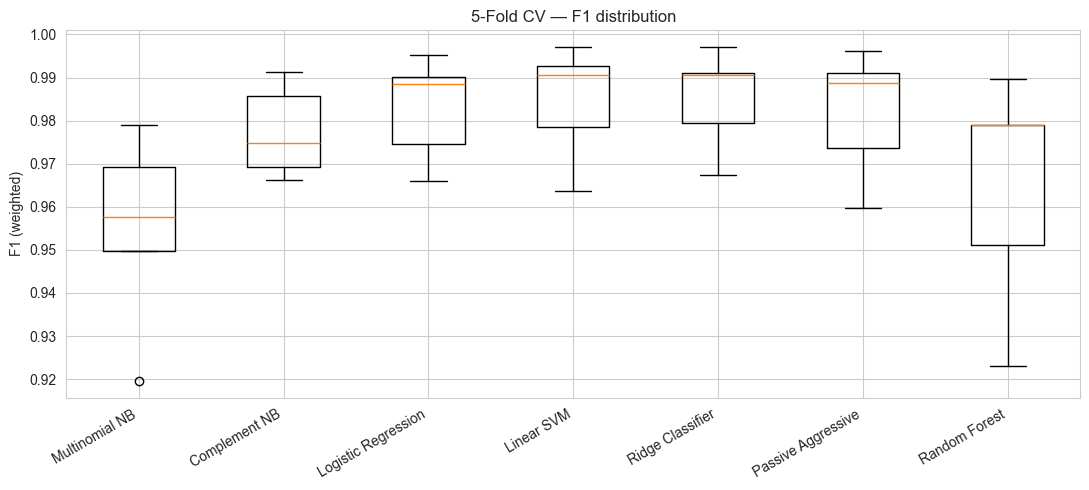

In [16]:
plt.figure(figsize=(11, 5))
plt.boxplot([cv_scores[k] for k in cv_scores], labels=list(cv_scores.keys()))
plt.xticks(rotation=30, ha='right'); plt.ylabel('F1 (weighted)')
plt.title('5-Fold CV — F1 distribution'); plt.tight_layout(); plt.show()

## 7. Hyperparameter Tuning — Best Performer

Best params: {'clf__C': 10.0, 'tfidf__ngram_range': (1, 3)}
Best CV F1: 0.9873



  Logistic Regression (Tuned)
  Accuracy    : 0.9888
  Precision   : 0.9889
  Recall      : 0.9888
  F1 Score    : 0.9888


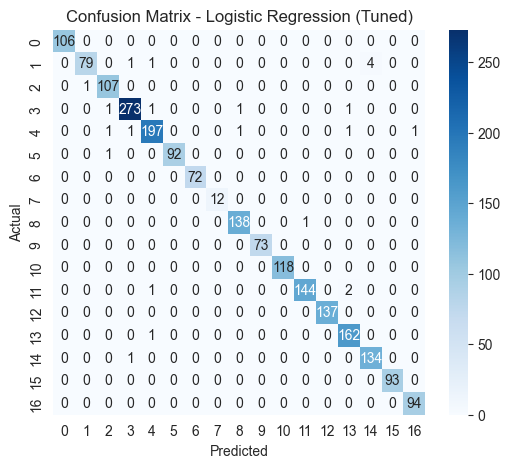

In [17]:
# Tune Logistic Regression over C and char n-gram range
from sklearn.pipeline import Pipeline
pipe = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='char_wb', sublinear_tf=True, max_features=12000)),
    ('clf', LogisticRegression(max_iter=2000)),
])
param_grid = {
    'tfidf__ngram_range': [(1, 2), (1, 3)],
    'clf__C': [1.0, 10.0],
}
grid = GridSearchCV(pipe, param_grid, cv=3, scoring='f1_weighted', n_jobs=-1, verbose=0)
grid.fit(X_train_txt, y_train)
print('Best params:', grid.best_params_)
print('Best CV F1:', round(grid.best_score_, 4))
best = grid.best_estimator_
y_pred = best.predict(X_test_txt)
tuned_metrics = evaluate_model('Logistic Regression (Tuned)', y_test, y_pred)
results.append(tuned_metrics)
plot_confusion_matrix(y_test, y_pred, 'Logistic Regression (Tuned)'); plt.show()

## 8. Sample Predictions

In [18]:
sample_idx = X_test_txt.index[:6]
best_model = models[comparison.iloc[0]['Model']]
sample_pred = best_model.predict(vectorizer.transform(X_test_txt.loc[sample_idx]))
out = pd.DataFrame({
    'text_excerpt': X_test_txt.loc[sample_idx].str.slice(0, 80).values,
    'predicted': sample_pred,
    'actual': y_test.loc[sample_idx].values,
})
out

,text_excerpt,predicted,actual
0,a nupedia foi licenciada inicialmente sob sua ...,4,11
1,jag är rädd att jag inte håller med,1,14
2,سيكون ذلك رائع ا فهناك زر أحمر في مكان ما,0,0
3,потерпи со мной минутку,12,12
4,innan filtrerades vissa wikipediasidor i ryssl...,16,14
5,en un réseau neuronal développé par google par...,2,4


## 9. Final Summary

In [19]:
final = compare_models(results)
final

,Model,Accuracy,Precision,Recall,F1 Score
0,Ridge Classifier,0.989776,0.989817,0.989776,0.989757
1,Passive Aggressive,0.988802,0.988842,0.988802,0.988795
2,Linear SVM,0.988802,0.988867,0.988802,0.988777
3,Logistic Regression (Tuned),0.988802,0.988866,0.988802,0.988772
4,Logistic Regression,0.986855,0.986898,0.986855,0.986789
5,Complement NB,0.979552,0.980199,0.979552,0.979434
6,Random Forest,0.972249,0.972610,0.972249,0.972260
7,Multinomial NB,0.959591,0.965537,0.959591,0.959659


### Key Takeaways

- Language Detection: text classification with TF-IDF features.
- 7 classifiers + 1 tuned variant evaluated on accuracy / precision / recall / F1 (weighted).
- Linear models (Logistic Regression, Linear SVM) and Naive Bayes dominate on sparse TF-IDF features.
- Cross-validation confirms whether the ranking is stable.

### Next Steps

- Try word embeddings (word2vec, GloVe) or transformer models (BERT) for richer representations.
- Add character n-grams for robustness to spelling variation.
- Calibrate probabilities if downstream decisions need confidence scores.